# Predicting FIFA World Cup Outcomes Through Upsets and Match Context

**Team Members:** Asher Kim (ck3292), Jason Liu (jl13869)  
**Course:** CSCI-UA 381 — Programming Tools for the Data Scientist

## Project Overview
The FIFA World Cup is the most-watched sporting event in the world, and outcomes are shaped by team
quality, historical trends, environmental conditions and pure unpredictability. This project investigates
**what drives unexpected (upset) outcomes** and **how match dynamics differ across tournament stages**
(group vs. knockout). With the 2026 World Cup hosted across the USA, Canada and Mexico — including
the high-altitude venues of Mexico City and Guadalajara. We also study **environmental factors**
such as altitude.

## Objectives
1. Define and model upset matches using ranking differences and match outcomes.
2. Build models to predict match outcomes in a multiclass setting (home_win / draw / away_win).
3. Compare model performance and feature importance between group and knockout stages.
4. Engineer features for recent team form, head-to-head history, and environmental context.
5. Surface data-driven insights relevant to the 2026 North America World Cup.

## Data Sources
- **`results.csv`** — all international football results (1872–2024) from the Kaggle dataset
  *martj42/international-football-results-from-1872-to-2017* (kept up-to-date by the maintainer).
- **`fifa_ranking-2024-06-20.csv`** — FIFA World Rankings published from 1992 onwards.
- **Engineered features** — recent form, head-to-head records, tournament stage, altitude proxy,
  rest days, host continent.

## Notebook Outline
1. **Data loading & cleaning**
2. **World Cup filtering, ranking merge, basic upset labelling**
3. **Recent-form / probabilistic-upset features** (`utils/features.py`)
4. **Extended feature engineering** — stage, head-to-head, host & altitude, rest days
5. **Comprehensive EDA** — descriptive stats, distributions, correlations, time trends
6. **Statistical tests** — chi-square, t-test, Mann-Whitney, ANOVA, correlations, Z-test
7. **Machine learning** — multiclass result models + binary upset model + stage-specific runs
8. **2026 World Cup insights** and conclusions


In [1]:
import pandas as pd

df = pd.read_csv("results.csv")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [2]:
df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='object')

In [3]:
df_wc = df[df["tournament"] == "FIFA World Cup"].copy()
df_wc.shape

(1036, 9)

In [4]:
def get_result(row):
    if row["home_score"] > row["away_score"]:
        return "home_win"
    elif row["home_score"] < row["away_score"]:
        return "away_win"
    else:
        return "draw"

df_wc["result"] = df_wc.apply(get_result, axis=1)

In [5]:
rankings = pd.read_csv("fifa_ranking-2024-06-20.csv")

df_wc["date"] = pd.to_datetime(df_wc["date"])
rankings["rank_date"] = pd.to_datetime(rankings["rank_date"])

# FIFA ranking data starts from 1992
df_wc = df_wc[df_wc["date"] >= "1992-12-31"].copy()

rankings = rankings.rename(columns={
    "country_full": "team",
    "rank_date": "date"
})

rankings = rankings[["date", "team", "rank", "total_points"]].copy()

team_fix = {
    "South Korea": "Korea Republic",
    "North Korea": "Korea DPR",
    "United States": "USA",
    "Iran": "IR Iran",
    "Ivory Coast": "Côte d'Ivoire",
    "DR Congo": "Congo DR",
    "Czech Republic": "Czechia",
    "Cape Verde": "Cabo Verde",
    "Curaçao": "Curacao"
}

df_wc["home_team_rank_name"] = df_wc["home_team"].replace(team_fix)
df_wc["away_team_rank_name"] = df_wc["away_team"].replace(team_fix)

def merge_team_ranking(matches, rankings, team_col, prefix):
    left = matches.sort_values(["date", team_col]).copy()
    right = rankings.sort_values(["date", "team"]).copy()
    
    merged = pd.merge_asof(
        left,
        right,
        on="date",
        left_by=team_col,
        right_by="team",
        direction="backward"
    )
    
    merged = merged.rename(columns={
        "rank": f"{prefix}_rank",
        "total_points": f"{prefix}_points"
    })
    
    merged = merged.drop(columns=["team"])
    return merged

df_wc = merge_team_ranking(df_wc, rankings, "home_team_rank_name", "home")
df_wc = merge_team_ranking(df_wc, rankings, "away_team_rank_name", "away")

print(df_wc[["home_rank", "away_rank"]].isna().sum())

df_wc = df_wc.dropna(subset=["home_rank", "away_rank"]).copy()

df_wc["rank_diff"] = df_wc["home_rank"] - df_wc["away_rank"]

def is_upset(row):
    if row["home_rank"] > row["away_rank"] and row["result"] == "home_win":
        return 1
    elif row["away_rank"] > row["home_rank"] and row["result"] == "away_win":
        return 1
    else:
        return 0

df_wc["upset"] = df_wc.apply(is_upset, axis=1)

df_wc[["date", "home_team", "away_team", "home_rank", "away_rank", "rank_diff", "result", "upset"]].head()

home_rank    1
away_rank    3
dtype: int64


,date,home_team,away_team,home_rank,away_rank,rank_diff,result,upset
0,1994-06-17,Germany,Bolivia,1.0,43.0,-42.0,home_win,0
1,1994-06-17,Spain,South Korea,5.0,37.0,-32.0,draw,0
2,1994-06-18,Italy,Republic of Ireland,4.0,14.0,-10.0,away_win,1
3,1994-06-18,Colombia,Romania,17.0,7.0,10.0,away_win,0
4,1994-06-18,United States,Switzerland,23.0,12.0,11.0,draw,0


In [6]:
df_wc = df_wc.dropna(subset=["home_rank", "away_rank"]).copy()

print(df_wc.shape)
print(df_wc["result"].value_counts())
print(df_wc["upset"].value_counts())

df_wc[["date", "home_team", "away_team", "home_score", "away_score",
       "home_rank", "away_rank", "rank_diff", "result", "upset"]].head(10)

(568, 18)
result
home_win    219
draw        189
away_win    160
Name: count, dtype: int64
upset
0    457
1    111
Name: count, dtype: int64


,date,home_team,away_team,home_score,away_score,home_rank,away_rank,rank_diff,result,upset
0,1994-06-17,Germany,Bolivia,1.0,0.0,1.0,43.0,-42.0,home_win,0
1,1994-06-17,Spain,South Korea,2.0,2.0,5.0,37.0,-32.0,draw,0
2,1994-06-18,Italy,Republic of Ireland,0.0,1.0,4.0,14.0,-10.0,away_win,1
3,1994-06-18,Colombia,Romania,1.0,3.0,17.0,7.0,10.0,away_win,0
4,1994-06-18,United States,Switzerland,1.0,1.0,23.0,12.0,11.0,draw,0
5,1994-06-19,Norway,Mexico,1.0,0.0,6.0,16.0,-10.0,home_win,0
6,1994-06-19,Belgium,Morocco,1.0,0.0,27.0,28.0,-1.0,home_win,0
7,1994-06-19,Cameroon,Sweden,2.0,2.0,24.0,10.0,14.0,draw,0
8,1994-06-20,Brazil,Russia,2.0,0.0,3.0,19.0,-16.0,home_win,0
9,1994-06-20,Netherlands,Saudi Arabia,2.0,1.0,2.0,34.0,-32.0,home_win,0


In [7]:
# Extra features
df_wc["rank_gap"] = abs(df_wc["rank_diff"])
df_wc["is_neutral"] = df_wc["neutral"].astype(int)

# Goal difference
df_wc["goal_diff"] = df_wc["home_score"] - df_wc["away_score"]

# Quick summary
print(df_wc[["rank_diff", "rank_gap", "is_neutral", "goal_diff", "upset"]].describe())

        rank_diff    rank_gap  is_neutral   goal_diff       upset
count  568.000000  568.000000  568.000000  496.000000  568.000000
mean    -2.815141   20.762324    0.901408    0.290323    0.195423
std     26.802682   17.160664    0.298376    1.802464    0.396875
min   -104.000000    1.000000    0.000000   -6.000000    0.000000
25%    -19.000000    7.750000    1.000000   -1.000000    0.000000
50%     -4.000000   16.500000    1.000000    0.000000    0.000000
75%     13.000000   29.000000    1.000000    1.000000    0.000000
max    104.000000  104.000000    1.000000    8.000000    1.000000


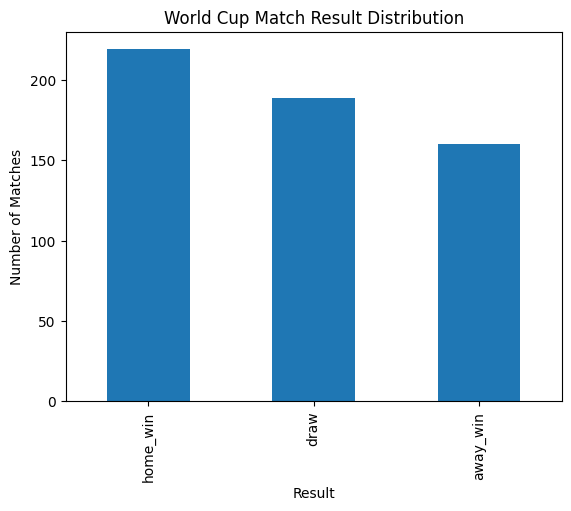

In [8]:
import matplotlib.pyplot as plt

df_wc["result"].value_counts().plot(kind="bar")
plt.title("World Cup Match Result Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.show()

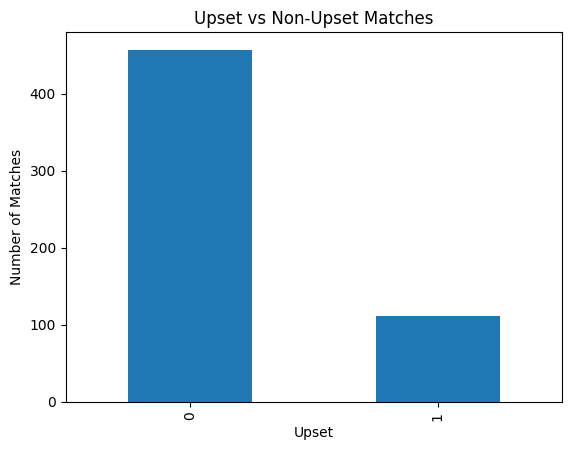

In [9]:
df_wc["upset"].value_counts().plot(kind="bar")
plt.title("Upset vs Non-Upset Matches")
plt.xlabel("Upset")
plt.ylabel("Number of Matches")
plt.show()

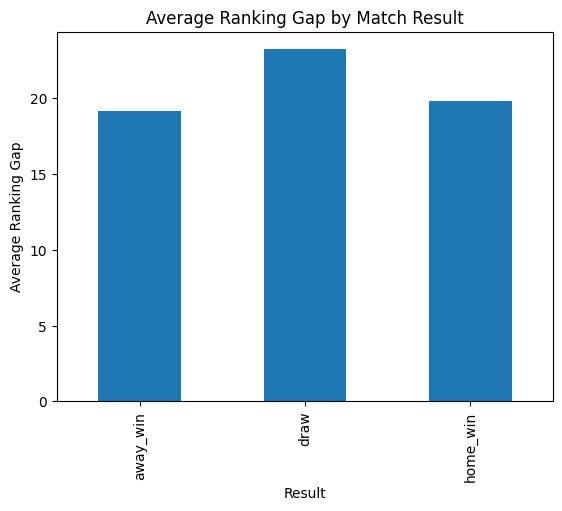

In [10]:
df_wc.groupby("result")["rank_gap"].mean().plot(kind="bar")
plt.title("Average Ranking Gap by Match Result")
plt.xlabel("Result")
plt.ylabel("Average Ranking Gap")
plt.show()

In [11]:
# --- Inlined helpers (originally in utils/features.py) ---
# `compute_recent_form` builds rolling last-N stats per team without leaking the
# current match's result into its own features. `label_upset` produces a
# probabilistic upset label using an Elo-style logistic on points/rank diff.
import numpy as np


def _long_form_matches(matches):
    """Convert matches to long form (one row per team per match)."""
    left = matches[["date", "home_team", "away_team", "home_score", "away_score"]].copy()
    home = pd.DataFrame({
        "date": left["date"], "team": left["home_team"], "opponent": left["away_team"],
        "goals_for": left["home_score"], "goals_against": left["away_score"], "is_home": 1,
    })
    away = pd.DataFrame({
        "date": left["date"], "team": left["away_team"], "opponent": left["home_team"],
        "goals_for": left["away_score"], "goals_against": left["home_score"], "is_home": 0,
    })
    long = pd.concat([home, away], ignore_index=True)
    long["date"] = pd.to_datetime(long["date"])
    long = long.sort_values(["team", "date"]).reset_index(drop=True)
    return long


def compute_recent_form(matches, window=5):
    """Attach rolling last-N form features (per team) onto a match-level DataFrame.

    Adds home_/away_ prefixed columns: lastN_wins, lastN_draws, lastN_losses,
    goals_lastN, conceded_lastN, recent_win_pct. Uses .shift(1) so the current
    match never leaks into its own predictors.
    """
    m = matches.copy()
    long = _long_form_matches(m)

    def outcome_row(row):
        if row["goals_for"] > row["goals_against"]:
            return "win"
        elif row["goals_for"] < row["goals_against"]:
            return "loss"
        else:
            return "draw"
    long["outcome"] = long.apply(outcome_row, axis=1)

    agg_list = []
    for _, grp in long.groupby("team", sort=False):
        grp = grp.sort_values("date").copy()
        # Rolling sums shifted by 1 so the current match doesn't leak in
        wins   = (grp["outcome"] == "win").astype(int).rolling(window=window, min_periods=0).sum().shift(1)
        draws  = (grp["outcome"] == "draw").astype(int).rolling(window=window, min_periods=0).sum().shift(1)
        losses = (grp["outcome"] == "loss").astype(int).rolling(window=window, min_periods=0).sum().shift(1)
        goals_for     = grp["goals_for"].rolling(window=window, min_periods=0).sum().shift(1)
        goals_against = grp["goals_against"].rolling(window=window, min_periods=0).sum().shift(1)

        grp["lastN_wins"]      = wins.fillna(0).astype(int)
        grp["lastN_draws"]     = draws.fillna(0).astype(int)
        grp["lastN_losses"]    = losses.fillna(0).astype(int)
        grp["goals_lastN"]     = goals_for.fillna(0).astype(int)
        grp["conceded_lastN"]  = goals_against.fillna(0).astype(int)
        grp["recent_win_pct"]  = (grp["lastN_wins"] / window).fillna(0)
        agg_list.append(grp)

    long_feats = pd.concat(agg_list, ignore_index=True)
    long_feats["match_key"] = (long_feats["team"] + "__" + long_feats["date"].astype(str)
                                + "__" + long_feats["is_home"].astype(str))

    m = m.copy()
    m["home_key"] = m["home_team"] + "__" + m["date"].astype(str) + "__1"
    m["away_key"] = m["away_team"] + "__" + m["date"].astype(str) + "__0"

    feats = long_feats.set_index("match_key")[
        ["lastN_wins", "lastN_draws", "lastN_losses", "goals_lastN", "conceded_lastN", "recent_win_pct"]
    ]

    def _get_feats_for_key(key):
        try:
            return feats.loc[key]
        except Exception:
            return pd.Series({"lastN_wins": 0, "lastN_draws": 0, "lastN_losses": 0,
                              "goals_lastN": 0, "conceded_lastN": 0, "recent_win_pct": 0})

    for idx, row in m.iterrows():
        h = _get_feats_for_key(row["home_key"])
        a = _get_feats_for_key(row["away_key"])
        for c in ["lastN_wins", "lastN_draws", "lastN_losses", "goals_lastN", "conceded_lastN", "recent_win_pct"]:
            m.at[idx, f"home_{c}"] = int(h[c]) if c != "recent_win_pct" else float(h[c])
            m.at[idx, f"away_{c}"] = int(a[c]) if c != "recent_win_pct" else float(a[c])

    for c in ["lastN_wins", "lastN_draws", "lastN_losses", "goals_lastN", "conceded_lastN"]:
        m[f"home_{c}"] = m[f"home_{c}"].fillna(0).astype(int)
        m[f"away_{c}"] = m[f"away_{c}"].fillna(0).astype(int)
    m["home_recent_win_pct"] = m["home_recent_win_pct"].fillna(0).astype(float)
    m["away_recent_win_pct"] = m["away_recent_win_pct"].fillna(0).astype(float)
    return m


def label_upset(row, gap_threshold=10, prob_threshold=0.35):
    """Probabilistic upset label. Returns (upset_binary, severity, p_home, p_away)."""
    home_points = row.get("home_points", None)
    away_points = row.get("away_points", None)
    home_rank   = row.get("home_rank", None)
    away_rank   = row.get("away_rank", None)

    p_home = None
    if pd.notna(home_points) and pd.notna(away_points):
        try:
            diff = float(away_points) - float(home_points)
            p_home = 1.0 / (1.0 + 10 ** (diff / 400.0))
        except Exception:
            p_home = None
    if p_home is None and pd.notna(home_rank) and pd.notna(away_rank):
        try:
            diff = float(away_rank) - float(home_rank)
            p_home = 1.0 / (1.0 + 10 ** (diff / 400.0))
        except Exception:
            p_home = 0.5
    if p_home is None:
        p_home = 0.5
    p_away = 1.0 - p_home

    if row.get("result") == "home_win":
        winner = "home"
    elif row.get("result") == "away_win":
        winner = "away"
    else:
        winner = None

    upset_binary, upset_severity = 0, 0.0
    if winner == "home":
        if p_home < prob_threshold:
            upset_binary, upset_severity = 1, 1.0 - p_home
        elif pd.notna(row.get("rank_gap")) and row.get("rank_gap") >= gap_threshold:
            upset_binary = 1
            upset_severity = max(upset_severity, row.get("rank_gap") / 100.0)
    elif winner == "away":
        if p_away < prob_threshold:
            upset_binary, upset_severity = 1, 1.0 - p_away
        elif pd.notna(row.get("rank_gap")) and row.get("rank_gap") >= gap_threshold:
            upset_binary = 1
            upset_severity = max(upset_severity, row.get("rank_gap") / 100.0)
    return int(upset_binary), float(upset_severity), float(p_home), float(p_away)


In [12]:
# Compute recent-form features (window=5)
df_wc = compute_recent_form(df_wc, window=5)

# Apply probabilistic upset labeling and attach columns
upset_cols = df_wc.apply(lambda r: label_upset(r, gap_threshold=10, prob_threshold=0.35), axis=1)
upset_df = pd.DataFrame(upset_cols.tolist(), columns=["upset_prob_binary", "upset_severity", "p_home", "p_away"])
df_wc = pd.concat([df_wc.reset_index(drop=True), upset_df.reset_index(drop=True)], axis=1)

# Quick sample
print(df_wc[["date", "home_team", "away_team", "result", "upset", "upset_prob_binary", "upset_severity", "p_home"]].head(10))


        date      home_team            away_team    result  upset  \
0 1994-06-17        Germany              Bolivia  home_win      0   
1 1994-06-17          Spain          South Korea      draw      0   
2 1994-06-18          Italy  Republic of Ireland  away_win      1   
3 1994-06-18       Colombia              Romania  away_win      0   
4 1994-06-18  United States          Switzerland      draw      0   
5 1994-06-19         Norway               Mexico  home_win      0   
6 1994-06-19        Belgium              Morocco  home_win      0   
7 1994-06-19       Cameroon               Sweden      draw      0   
8 1994-06-20         Brazil               Russia  home_win      0   
9 1994-06-20    Netherlands         Saudi Arabia  home_win      0   

   upset_prob_binary  upset_severity    p_home  
0                  1            0.42  0.535916  
1                  0            0.00  0.525881  
2                  1            0.10  0.505756  
3                  1            0.10  0.4942

In [13]:
# Sanity checks
new_cols = [c for c in df_wc.columns if c.startswith("home_") or c.startswith("away_")]
print("New feature columns:", new_cols)
assert "home_lastN_wins" in df_wc.columns
assert "away_recent_win_pct" in df_wc.columns
print("Counts: upsets (old rule)", df_wc["upset"].sum(), "upsets (prob rule)", df_wc["upset_prob_binary"].sum())
df_wc[["home_team", "away_team", "home_lastN_wins", "away_lastN_wins", "home_recent_win_pct", "away_recent_win_pct"]].head(8)


New feature columns: ['home_team', 'away_team', 'home_score', 'away_score', 'home_team_rank_name', 'away_team_rank_name', 'home_rank', 'home_points', 'away_rank', 'away_points', 'home_key', 'away_key', 'home_lastN_wins', 'away_lastN_wins', 'home_lastN_draws', 'away_lastN_draws', 'home_lastN_losses', 'away_lastN_losses', 'home_goals_lastN', 'away_goals_lastN', 'home_conceded_lastN', 'away_conceded_lastN', 'home_recent_win_pct', 'away_recent_win_pct']
Counts: upsets (old rule) 111 upsets (prob rule) 263


,home_team,away_team,home_lastN_wins,away_lastN_wins,home_recent_win_pct,away_recent_win_pct
0,Germany,Bolivia,0,0,0.0,0.0
1,Spain,South Korea,0,0,0.0,0.0
2,Italy,Republic of Ireland,0,0,0.0,0.0
3,Colombia,Romania,0,0,0.0,0.0
4,United States,Switzerland,0,0,0.0,0.0
5,Norway,Mexico,0,0,0.0,0.0
6,Belgium,Morocco,0,0,0.0,0.0
7,Cameroon,Sweden,0,0,0.0,0.0


## 4. Extended Feature Engineering

We expand the feature set with four new groups of variables that the existing rank- and form-based
features do not capture:

| Feature group | Columns added | Why it matters |
|---|---|---|
| **Tournament stage** | `stage`, `is_knockout`, `match_num_in_year` | Knockout matches behave differently — draws are rarer, stakes are higher |
| **Head-to-head history** | `h2h_home_wins_prior`, `h2h_away_wins_prior`, `h2h_draws_prior`, `h2h_total_prior`, `h2h_home_win_pct` | Some pairs of national teams have persistent rivalries that rankings miss |
| **Host & altitude context** | `altitude_m`, `high_altitude`, `host_continent` | Especially relevant for the 2026 World Cup (Mexico City ≈ 2,240 m) |
| **Rest / fatigue** | `home_rest_days`, `away_rest_days` | Short rest between matches affects performance |

All historical features are constructed with a strict *as-of-match-date* rule (no leakage of the
current match's outcome into its own predictors).


In [14]:
# The teammate's earlier cells filtered NaN ranks but not NaN scores.
# Without this step, downstream statistical tests on goals would propagate NaNs.
n_before = len(df_wc)
df_wc = df_wc.dropna(subset=["home_score", "away_score"]).copy()
df_wc["home_score"] = df_wc["home_score"].astype(int)
df_wc["away_score"] = df_wc["away_score"].astype(int)
print(f"Dropped {n_before - len(df_wc)} rows with missing scores; remaining: {len(df_wc)}")

# The dataset has no explicit round label, so we infer stage from match position within
# each World Cup edition. The first N matches of each edition are group-stage; the rest
# are knockout. N depends on tournament format (24 vs 32 teams).
df_wc["year"] = df_wc["date"].dt.year

group_matches_by_year = {
    1994: 36, 1998: 48, 2002: 48, 2006: 48, 2010: 48,
    2014: 48, 2018: 48, 2022: 48,
    # Older tournaments retained for completeness even if rankings start in 1992
    1990: 36, 1986: 36, 1982: 36, 1978: 24, 1974: 24,
}

df_wc = df_wc.sort_values(["year", "date"]).reset_index(drop=True)
df_wc["match_num_in_year"] = df_wc.groupby("year").cumcount() + 1

def assign_stage(row):
    n_group = group_matches_by_year.get(row["year"], 36)
    return "group" if row["match_num_in_year"] <= n_group else "knockout"

df_wc["stage"] = df_wc.apply(assign_stage, axis=1)
df_wc["is_knockout"] = (df_wc["stage"] == "knockout").astype(int)

print("\nStage distribution:")
print(df_wc["stage"].value_counts())
print("\nUpset rate by stage:")
print(df_wc.groupby("stage")["upset"].mean().round(3))


Dropped 72 rows with missing scores; remaining: 496

Stage distribution:
stage
group       372
knockout    124
Name: count, dtype: int64

Upset rate by stage:
stage
group       0.231
knockout    0.202
Name: upset, dtype: float64


In [15]:
import numpy as np

df_wc = df_wc.sort_values("date").reset_index(drop=True)

def pair_key(t1, t2):
    return tuple(sorted([t1, t2]))

h2h_running = {}
prior_home_wins, prior_away_wins, prior_draws, prior_total = [], [], [], []

for _, row in df_wc.iterrows():
    key = pair_key(row["home_team"], row["away_team"])
    counts = h2h_running.get(key, {"home_wins": 0, "away_wins": 0, "draws": 0})
    prior_home_wins.append(counts["home_wins"])
    prior_away_wins.append(counts["away_wins"])
    prior_draws.append(counts["draws"])
    prior_total.append(counts["home_wins"] + counts["away_wins"] + counts["draws"])
    if row["result"] == "home_win":
        counts["home_wins"] += 1
    elif row["result"] == "away_win":
        counts["away_wins"] += 1
    else:
        counts["draws"] += 1
    h2h_running[key] = counts

df_wc["h2h_home_wins_prior"] = prior_home_wins
df_wc["h2h_away_wins_prior"] = prior_away_wins
df_wc["h2h_draws_prior"]     = prior_draws
df_wc["h2h_total_prior"]     = prior_total
df_wc["h2h_home_win_pct"]    = (df_wc["h2h_home_wins_prior"] /
                                df_wc["h2h_total_prior"].replace(0, np.nan)).fillna(0.5)

print(df_wc[["home_team", "away_team", "h2h_total_prior", "h2h_home_win_pct"]].tail(8))


       home_team  away_team  h2h_total_prior  h2h_home_win_pct
488  Netherlands  Argentina                3          0.333333
489      Croatia     Brazil                2          1.000000
490      England     France                0          0.500000
491      Morocco   Portugal                1          1.000000
492    Argentina    Croatia                2          0.500000
493       France    Morocco                0          0.500000
494      Croatia    Morocco                1          0.000000
495    Argentina     France                1          1.000000


In [16]:
# Altitude lookup for cities that recur in WC matches. Cities not in the table default to 0 m.
# Especially relevant for the 2026 hosts — Mexico City and Guadalajara sit well above 1,500 m.
city_altitude_m = {
    "Mexico City": 2240, "Toluca": 2660, "Guadalajara": 1566, "Monterrey": 540,
    "Quito": 2850, "La Paz": 3640, "Bogotá": 2640, "Bogota": 2640,
    "Johannesburg": 1753, "Pretoria": 1339, "Bloemfontein": 1395,
    "London": 11, "Paris": 35, "Rome": 21, "Berlin": 34, "Moscow": 156,
    "Doha": 10, "Buenos Aires": 25, "Rio de Janeiro": 5, "Sao Paulo": 760,
    "Madrid": 667, "Munich": 520, "Barcelona": 12, "Tokyo": 40,
    "Seoul": 38, "New York": 10, "Los Angeles": 89, "Dallas": 131,
    "Houston": 13, "Atlanta": 320, "Miami": 2, "Boston": 43, "Chicago": 181,
    "Toronto": 76, "Vancouver": 70, "Seattle": 56,
}
df_wc["altitude_m"]    = df_wc["city"].map(city_altitude_m).fillna(0).astype(int)
df_wc["high_altitude"] = (df_wc["altitude_m"] >= 1500).astype(int)

country_to_continent = {
    "Brazil": "S.America", "Argentina": "S.America", "Uruguay": "S.America",
    "Chile":  "S.America", "Colombia":  "S.America", "Peru":    "S.America",
    "Mexico": "N.America", "USA":       "N.America", "Canada":  "N.America",
    "United States": "N.America",
    "Germany": "Europe", "France": "Europe", "Italy": "Europe",
    "Spain":   "Europe", "England": "Europe", "Russia": "Europe",
    "South Africa": "Africa", "Morocco": "Africa", "Egypt": "Africa",
    "South Korea":  "Asia",   "Japan":   "Asia",   "Qatar": "Asia",
    "Saudi Arabia": "Asia",   "Australia": "Oceania",
}
df_wc["host_continent"] = df_wc["country"].map(country_to_continent).fillna("Other")

df_wc = df_wc.sort_values("date").reset_index(drop=True)
last_match_date = {}
home_rest, away_rest = [], []
for _, row in df_wc.iterrows():
    h_prev = last_match_date.get(row["home_team"])
    a_prev = last_match_date.get(row["away_team"])
    home_rest.append((row["date"] - h_prev).days if h_prev is not None else np.nan)
    away_rest.append((row["date"] - a_prev).days if a_prev is not None else np.nan)
    last_match_date[row["home_team"]] = row["date"]
    last_match_date[row["away_team"]] = row["date"]

median_gap = pd.Series(home_rest + away_rest).dropna().median()
df_wc["home_rest_days"] = pd.Series(home_rest).fillna(median_gap)
df_wc["away_rest_days"] = pd.Series(away_rest).fillna(median_gap)

print("Altitude distribution (m):")
print(df_wc["altitude_m"].describe().round(1))
print("\nHost continent counts:")
print(df_wc["host_continent"].value_counts())
print("\nHigh-altitude matches:", int(df_wc["high_altitude"].sum()), "of", len(df_wc))


Altitude distribution (m):
count     496.0
mean      101.0
std       364.2
min         0.0
25%         0.0
50%         0.0
75%         0.0
max      1753.0
Name: altitude_m, dtype: float64

Host continent counts:
host_continent
Europe       188
Asia         128
Africa        64
S.America     64
N.America     52
Name: count, dtype: int64

High-altitude matches: 15 of 496


## 5. Exploratory Data Analysis

We characterize the data with at least four distinct statistical techniques (descriptive
statistics, skew/kurtosis, correlation analysis and group-wise summaries) and a variety of
visualisation types (line, KDE, boxplot, stacked bar, heatmap, scatter, bar). The aim is to
surface relationships between **rankings**, **stage**, **environmental context** and the
**upset / outcome** structure of the data.


In [17]:
print("=== Descriptive statistics for key numerical features ===")
num_cols = ["home_rank", "away_rank", "rank_gap", "home_points", "away_points",
            "goal_diff", "home_score", "away_score",
            "home_recent_win_pct", "away_recent_win_pct"]
desc = df_wc[num_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T
print(desc.round(2))

print("\n=== Distribution shape (skew, kurtosis) ===")
shape_stats = pd.DataFrame({
    "skew":     df_wc[num_cols].skew(),
    "kurtosis": df_wc[num_cols].kurtosis(),
}).round(3)
print(shape_stats)

print("\n=== Pearson correlation with the upset label ===")
print(df_wc[num_cols + ["upset"]].corr()["upset"].sort_values().round(3))

print("\n=== Upset rate and goals by stage ===")
df_wc["total_goals"] = df_wc["home_score"] + df_wc["away_score"]
print(df_wc.groupby("stage").agg(
    matches=("upset", "size"),
    upset_rate=("upset", "mean"),
    avg_goals=("total_goals", "mean"),
    median_goals=("total_goals", "median"),
).round(3))


=== Descriptive statistics for key numerical features ===
                     count    mean     std   min   10%     25%    50%     75%  \
home_rank            496.0   19.35   17.29   1.0   2.0    6.00   15.0    28.0   
away_rank            496.0   21.61   16.14   1.0   4.0    8.75   19.0    31.0   
rank_gap             496.0   18.80   15.37   1.0   3.0    7.00   15.0    27.0   
home_points          496.0  808.03  550.91  35.0  55.0  526.00  746.0  1175.0   
away_points          496.0  787.30  539.91  35.0  53.0  564.00  727.0  1082.0   
goal_diff            496.0    0.29    1.80  -6.0  -2.0   -1.00    0.0     1.0   
home_score           496.0    1.42    1.32   0.0   0.0    0.00    1.0     2.0   
away_score           496.0    1.13    1.09   0.0   0.0    0.00    1.0     2.0   
home_recent_win_pct  496.0    0.38    0.27   0.0   0.0    0.20    0.4     0.6   
away_recent_win_pct  496.0    0.28    0.25   0.0   0.0    0.00    0.2     0.4   

                         90%     max  
home_rank  

/var/folders/cz/9s1fvts90jbgnbwcxmdb38l80000gn/T/ipykernel_37396/3337184215.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_wc, x="result", y="total_goals", ax=axes[0, 2],


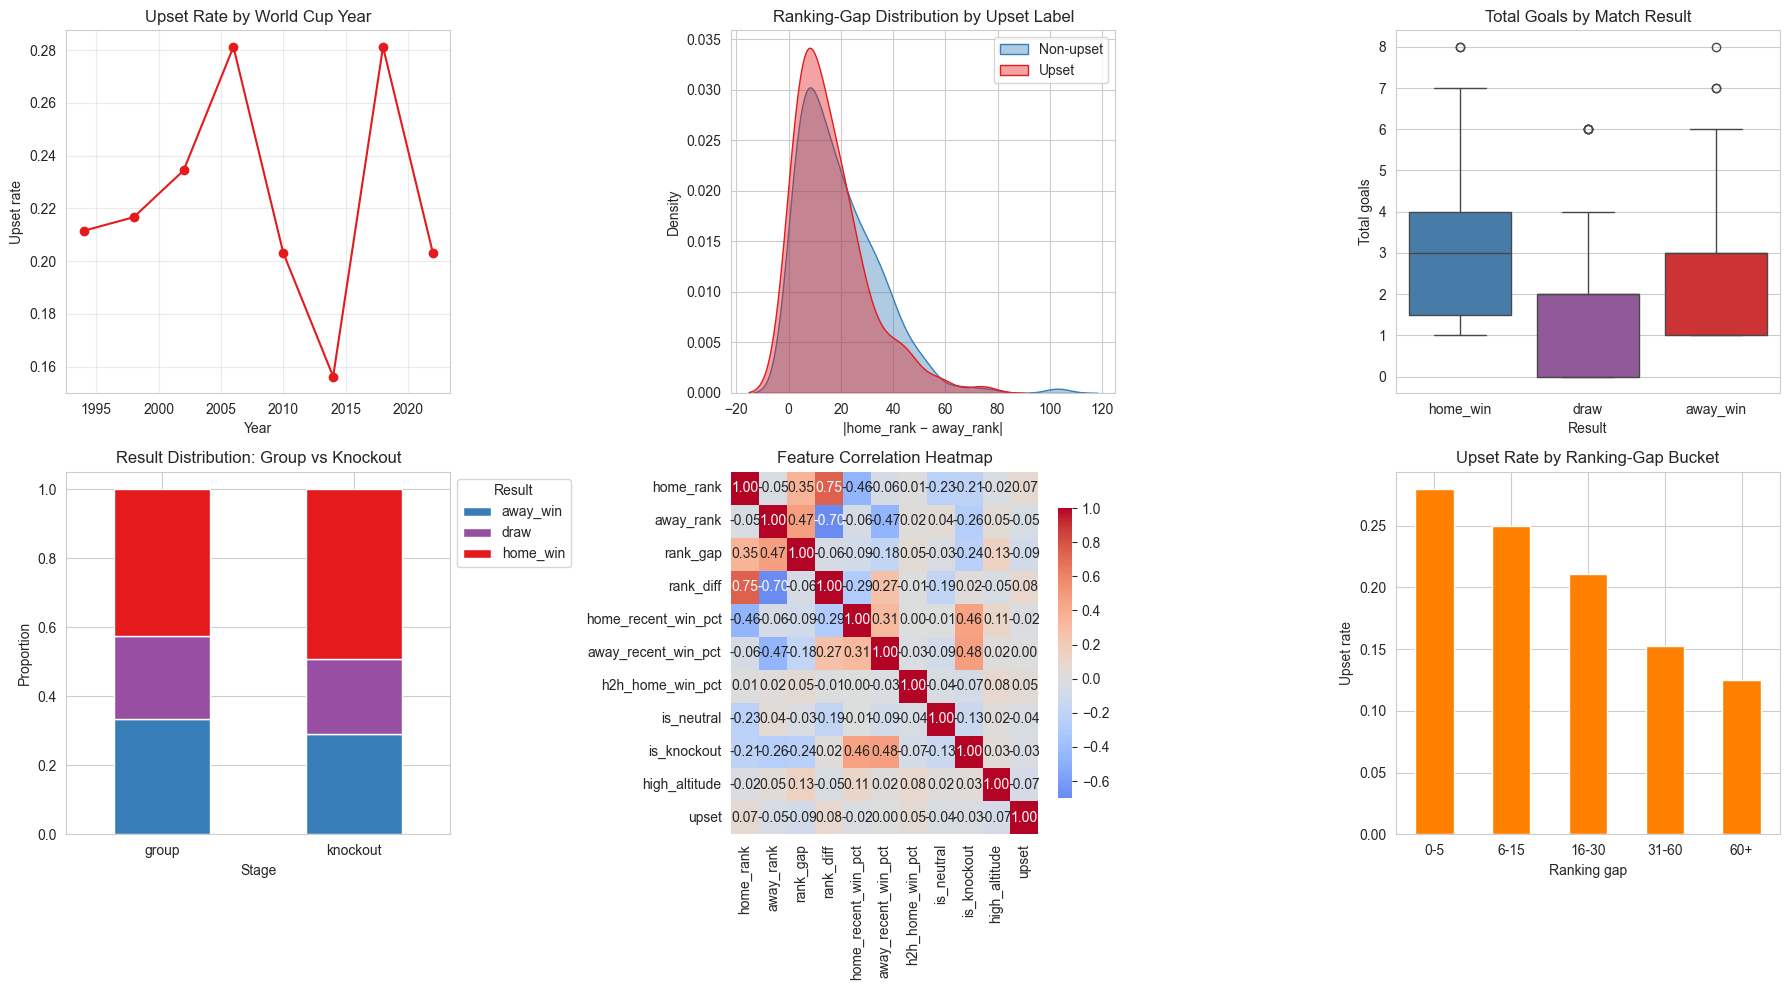

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# (1) Upset rate by World Cup year — line plot showing the time trend
upset_by_year = df_wc.groupby("year")["upset"].mean()
axes[0, 0].plot(upset_by_year.index, upset_by_year.values, marker="o", color="#e41a1c")
axes[0, 0].set_title("Upset Rate by World Cup Year")
axes[0, 0].set_xlabel("Year"); axes[0, 0].set_ylabel("Upset rate")
axes[0, 0].grid(True, alpha=0.4)

# (2) Ranking-gap KDE: upset vs non-upset
sns.kdeplot(data=df_wc[df_wc["upset"] == 0], x="rank_gap",
            ax=axes[0, 1], label="Non-upset", fill=True, alpha=0.4, color="#377eb8")
sns.kdeplot(data=df_wc[df_wc["upset"] == 1], x="rank_gap",
            ax=axes[0, 1], label="Upset",     fill=True, alpha=0.4, color="#e41a1c")
axes[0, 1].set_title("Ranking-Gap Distribution by Upset Label")
axes[0, 1].set_xlabel("|home_rank − away_rank|"); axes[0, 1].legend()

# (3) Total goals by result type — boxplot
sns.boxplot(data=df_wc, x="result", y="total_goals", ax=axes[0, 2],
            palette=["#377eb8", "#984ea3", "#e41a1c"])
axes[0, 2].set_title("Total Goals by Match Result")
axes[0, 2].set_xlabel("Result"); axes[0, 2].set_ylabel("Total goals")

# (4) Result distribution by stage — stacked proportional bar
stage_result = df_wc.groupby(["stage", "result"]).size().unstack(fill_value=0)
stage_result_pct = stage_result.div(stage_result.sum(axis=1), axis=0)
stage_result_pct.plot(kind="bar", stacked=True, ax=axes[1, 0],
                      color=["#377eb8", "#984ea3", "#e41a1c"])
axes[1, 0].set_title("Result Distribution: Group vs Knockout")
axes[1, 0].set_xlabel("Stage"); axes[1, 0].set_ylabel("Proportion")
axes[1, 0].legend(title="Result", bbox_to_anchor=(1.0, 1.0))
axes[1, 0].tick_params(axis="x", rotation=0)

# (5) Correlation heatmap
corr_cols = ["home_rank", "away_rank", "rank_gap", "rank_diff",
             "home_recent_win_pct", "away_recent_win_pct",
             "h2h_home_win_pct", "is_neutral", "is_knockout",
             "high_altitude", "upset"]
corr_cols = [c for c in corr_cols if c in df_wc.columns]
sns.heatmap(df_wc[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=axes[1, 1], cbar_kws={"shrink": 0.8})
axes[1, 1].set_title("Feature Correlation Heatmap")

# (6) Upset rate by ranking-gap bucket — bar
df_wc["rank_gap_bucket"] = pd.cut(df_wc["rank_gap"],
                                   bins=[-0.1, 5, 15, 30, 60, 200],
                                   labels=["0-5", "6-15", "16-30", "31-60", "60+"])
gap_upset = df_wc.groupby("rank_gap_bucket", observed=True)["upset"].mean()
gap_upset.plot(kind="bar", ax=axes[1, 2], color="#ff7f00")
axes[1, 2].set_title("Upset Rate by Ranking-Gap Bucket")
axes[1, 2].set_xlabel("Ranking gap"); axes[1, 2].set_ylabel("Upset rate")
axes[1, 2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


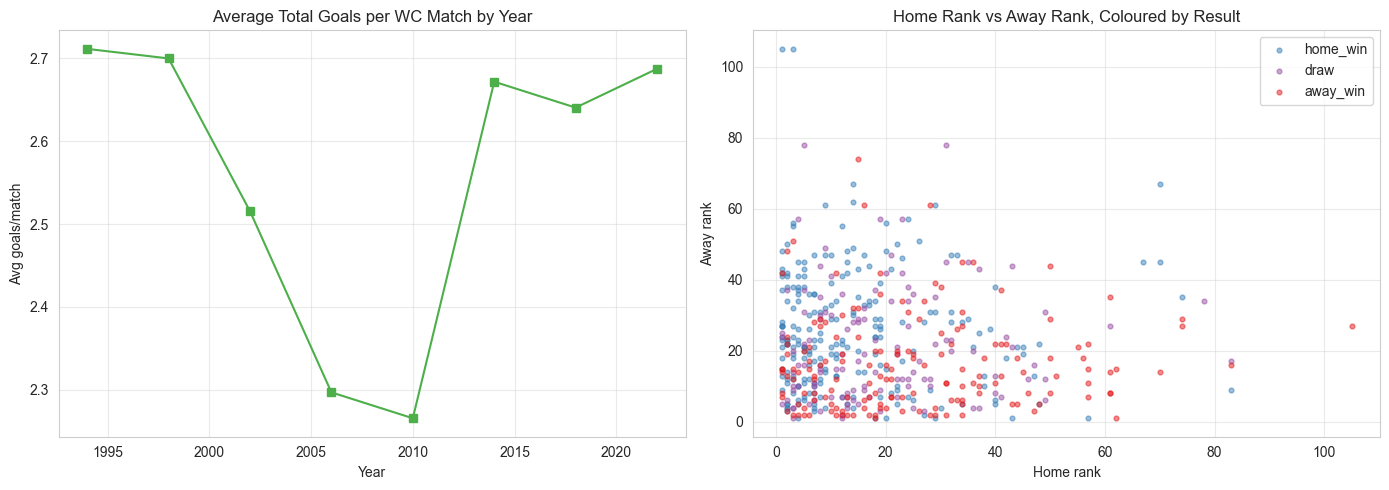

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Goals per match over time — line plot
goals_by_year = df_wc.groupby("year")["total_goals"].mean()
axes[0].plot(goals_by_year.index, goals_by_year.values, marker="s", color="#4daf4a")
axes[0].set_title("Average Total Goals per WC Match by Year")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Avg goals/match")
axes[0].grid(True, alpha=0.4)

# Home rank vs away rank scatter, colour-coded by result
for r, color in [("home_win", "#377eb8"), ("draw", "#984ea3"), ("away_win", "#e41a1c")]:
    sub = df_wc[df_wc["result"] == r]
    axes[1].scatter(sub["home_rank"], sub["away_rank"], c=color, s=12, alpha=0.5, label=r)
axes[1].set_title("Home Rank vs Away Rank, Coloured by Result")
axes[1].set_xlabel("Home rank"); axes[1].set_ylabel("Away rank")
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


## 6. Statistical Tests

We run six tests targeted at the project's research questions. Each test is matched to the
data type (categorical vs continuous) and the question it answers:

1. **Chi-square test of independence** — is the upset rate independent of tournament stage?
2. **Welch's t-test** — does ranking gap differ between upset and non-upset matches?
3. **Mann-Whitney U test** — non-parametric robustness check for the same comparison.
4. **One-way ANOVA** — do total goals differ across the three result classes?
5. **Pearson and Spearman correlation** — do larger ranking gaps imply larger goal margins?
6. **Two-proportion Z-test** — does the home-win rate differ between neutral and non-neutral venues?


In [20]:
from scipy import stats as sps
import numpy as np

# --- 6.1 Chi-square: upset vs stage ---
print("=== 1. Chi-square test: upset vs stage ===")
contingency = pd.crosstab(df_wc["stage"], df_wc["upset"])
print(contingency)
chi2, p, dof, expected = sps.chi2_contingency(contingency)
print(f"  chi2 = {chi2:.3f}, p = {p:.4f}, dof = {dof}")
print("  →", "Significant" if p < 0.05 else "Not significant", "at alpha=0.05")

# --- 6.2 Welch's t-test on rank_gap ---
print("\n=== 2. Welch's t-test: rank_gap, upset vs non-upset ===")
g0 = df_wc.loc[df_wc["upset"] == 0, "rank_gap"]
g1 = df_wc.loc[df_wc["upset"] == 1, "rank_gap"]
t_stat, p = sps.ttest_ind(g1, g0, equal_var=False)
print(f"  mean(non-upset) = {g0.mean():.2f}, mean(upset) = {g1.mean():.2f}")
print(f"  t = {t_stat:.3f}, p = {p:.4g}")

# --- 6.3 Mann-Whitney U on rank_gap ---
print("\n=== 3. Mann-Whitney U: rank_gap, upset vs non-upset ===")
u_stat, p = sps.mannwhitneyu(g1, g0, alternative="two-sided")
print(f"  U = {u_stat:.1f}, p = {p:.4g}")

# --- 6.4 One-way ANOVA on total_goals across result classes ---
print("\n=== 4. One-way ANOVA: total_goals across results ===")
groups = [df_wc.loc[df_wc["result"] == r, "total_goals"]
          for r in ["home_win", "draw", "away_win"]]
f_stat, p = sps.f_oneway(*groups)
print(f"  F = {f_stat:.3f}, p = {p:.4g}")

# --- 6.5 Correlation between rank_gap and |goal_diff| ---
print("\n=== 5. Correlations: rank_gap vs |goal_diff| ===")
abs_gd = df_wc["goal_diff"].abs()
pearson_r,  pearson_p  = sps.pearsonr(df_wc["rank_gap"], abs_gd)
spearman_r, spearman_p = sps.spearmanr(df_wc["rank_gap"], abs_gd)
print(f"  Pearson  r = {pearson_r:.3f}, p = {pearson_p:.4g}")
print(f"  Spearman ρ = {spearman_r:.3f}, p = {spearman_p:.4g}")

# --- 6.6 Two-proportion Z-test: home_win at neutral vs non-neutral ---
print("\n=== 6. Two-proportion Z-test: home_win, neutral vs non-neutral ===")
hw = (df_wc["result"] == "home_win").astype(int)
n_neutral = int((df_wc["is_neutral"] == 1).sum())
n_nonneut = int((df_wc["is_neutral"] == 0).sum())
hw_neutral = int(hw[df_wc["is_neutral"] == 1].sum())
hw_nonneut = int(hw[df_wc["is_neutral"] == 0].sum())
p1 = hw_neutral / n_neutral if n_neutral else float("nan")
p2 = hw_nonneut / n_nonneut if n_nonneut else float("nan")
p_pool = (hw_neutral + hw_nonneut) / (n_neutral + n_nonneut)
se = (p_pool * (1 - p_pool) * (1 / n_neutral + 1 / n_nonneut)) ** 0.5 if n_neutral and n_nonneut else float("nan")
z = (p1 - p2) / se if se and not np.isnan(se) else float("nan")
p_z = 2 * (1 - sps.norm.cdf(abs(z))) if not np.isnan(z) else float("nan")
print(f"  home_win rate (neutral)     = {p1:.3f}  (n={n_neutral})")
print(f"  home_win rate (non-neutral) = {p2:.3f}  (n={n_nonneut})")
print(f"  z = {z:.3f}, p = {p_z:.4g}")


=== 1. Chi-square test: upset vs stage ===
upset       0   1
stage            
group     286  86
knockout   99  25
  chi2 = 0.313, p = 0.5756, dof = 1
  → Not significant at alpha=0.05

=== 2. Welch's t-test: rank_gap, upset vs non-upset ===
  mean(non-upset) = 19.56, mean(upset) = 16.18
  t = -2.185, p = 0.03007

=== 3. Mann-Whitney U: rank_gap, upset vs non-upset ===
  U = 18493.5, p = 0.03071

=== 4. One-way ANOVA: total_goals across results ===
  F = 15.830, p = 2.172e-07

=== 5. Correlations: rank_gap vs |goal_diff| ===
  Pearson  r = 0.136, p = 0.002441
  Spearman ρ = 0.107, p = 0.01709

=== 6. Two-proportion Z-test: home_win, neutral vs non-neutral ===
  home_win rate (neutral)     = 0.437  (n=449)
  home_win rate (non-neutral) = 0.489  (n=47)
  z = -0.694, p = 0.4877


## 7. Machine Learning Models

We train **multiclass classifiers** (home_win / draw / away_win) and a **binary upset classifier**
using a **time-based split** — train on World Cups before 2018, test on the 2018 and 2022 editions.
This mimics real forecasting (no information leaks from the future). We compare:

- Logistic regression (linear baseline, with feature scaling)
- Random forest (non-linear, robust to mixed feature scales)
- Gradient boosting (typically the strongest tabular classifier)

We report **accuracy** and **macro-F1**, plot the confusion matrix and feature importances of
the best model, and run **stage-specific** models to see how predictors shift between group and
knockout football. Finally we train a binary upset model and plot its ROC curve.


In [21]:
# --- 7.1 Feature set + time-based split ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)

feat_cols = [
    "home_rank", "away_rank", "rank_gap", "rank_diff",
    "home_points", "away_points",
    "home_recent_win_pct", "away_recent_win_pct",
    "home_lastN_wins", "away_lastN_wins",
    "home_lastN_losses", "away_lastN_losses",
    "home_goals_lastN", "away_goals_lastN",
    "home_conceded_lastN", "away_conceded_lastN",
    "h2h_home_win_pct", "h2h_total_prior",
    "is_neutral", "is_knockout", "high_altitude", "altitude_m",
    "home_rest_days", "away_rest_days",
]
feat_cols = [c for c in feat_cols if c in df_wc.columns]
print(f"Using {len(feat_cols)} features.")

ml_df = df_wc.dropna(subset=feat_cols + ["result"]).copy()

# Time-based split — train on pre-2018 World Cups, test on 2018 + 2022
train_mask = ml_df["year"] < 2018
X_train = ml_df.loc[train_mask, feat_cols]
y_train = ml_df.loc[train_mask, "result"]
X_test  = ml_df.loc[~train_mask, feat_cols]
y_test  = ml_df.loc[~train_mask, "result"]
print(f"Train: {len(X_train)} matches (years <2018) | Test: {len(X_test)} matches (>=2018)")
print("Train class distribution:")
print(y_train.value_counts(normalize=True).round(3))

# --- Reference baseline: always predict the most common training class ---
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train, y_train)
base_pred = baseline.predict(X_test)
base_acc  = accuracy_score(y_test, base_pred)
base_f1   = f1_score(y_test, base_pred, average="macro")
print(f"\nMost-frequent-class baseline — accuracy: {base_acc:.3f}, macro_F1: {base_f1:.3f}")

# --- 7.2 Train and compare three models on the time-based test set ---
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, max_depth=8, min_samples_leaf=3,
        random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
    })

results_df = pd.DataFrame(rows).set_index("model").round(3)
print("\nTime-split model comparison (test set 2018+):")
print(results_df)

# --- 7.2b Stratified 5-fold CV on the full dataset for robustness ---
print("\n5-fold stratified CV (full dataset) — accuracy ± std and macro_F1 ± std:")
X_all = ml_df[feat_cols]
y_all = ml_df["result"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
for name, model in models.items():
    acc_scores = cross_val_score(model, X_all, y_all, cv=cv, scoring="accuracy", n_jobs=-1)
    f1_scores  = cross_val_score(model, X_all, y_all, cv=cv, scoring="f1_macro", n_jobs=-1)
    cv_rows.append({
        "model":    name,
        "cv_acc":   f"{acc_scores.mean():.3f} ± {acc_scores.std():.3f}",
        "cv_f1":    f"{f1_scores.mean():.3f} ± {f1_scores.std():.3f}",
    })
print(pd.DataFrame(cv_rows).set_index("model"))

# --- 7.2c Best model classification report on the time-split test ---
best_name  = results_df["macro_f1"].idxmax()
best_model = models[best_name]
best_pred  = best_model.predict(X_test)
print(f"\nClassification report — best model on time-split test: {best_name}")
print(classification_report(y_test, best_pred, digits=3))


Using 24 features.
Train: 368 matches (years <2018) | Test: 128 matches (>=2018)
Train class distribution:
result
home_win    0.451
away_win    0.307
draw        0.242
Name: proportion, dtype: float64

Most-frequent-class baseline — accuracy: 0.414, macro_F1: 0.195



Time-split model comparison (test set 2018+):
                     accuracy  macro_f1
model                                  
Logistic Regression     0.469     0.367
Random Forest           0.531     0.418
Gradient Boosting       0.461     0.438

5-fold stratified CV (full dataset) — accuracy ± std and macro_F1 ± std:


                            cv_acc          cv_f1
model                                            
Logistic Regression  0.506 ± 0.034  0.404 ± 0.034
Random Forest        0.512 ± 0.061  0.404 ± 0.056
Gradient Boosting    0.478 ± 0.061  0.413 ± 0.072

Classification report — best model on time-split test: Gradient Boosting
              precision    recall  f1-score   support

    away_win      0.556     0.426     0.482        47
        draw      0.300     0.321     0.310        28
    home_win      0.484     0.566     0.522        53

    accuracy                          0.461       128
   macro avg      0.446     0.438     0.438       128
weighted avg      0.470     0.461     0.461       128



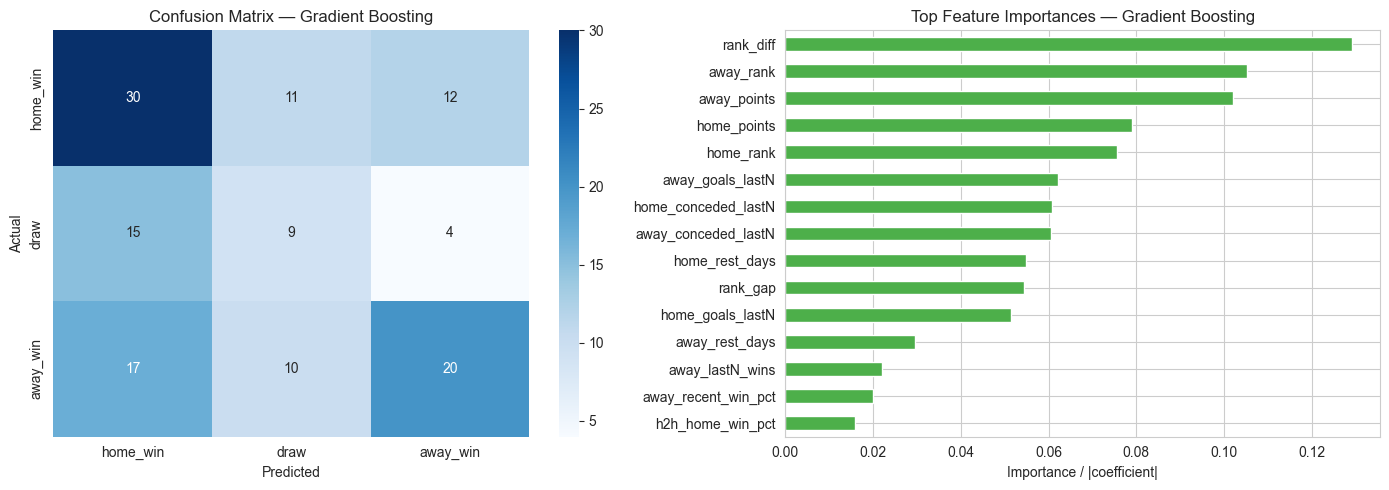

In [22]:
# --- 7.3 Confusion matrix + feature importance for the best model ---
labels = ["home_win", "draw", "away_win"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, best_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(f"Confusion Matrix — {best_name}")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feat_cols)
elif hasattr(best_model, "named_steps") and hasattr(best_model.named_steps["clf"], "coef_"):
    importances = pd.Series(np.abs(best_model.named_steps["clf"].coef_).mean(axis=0),
                            index=feat_cols)
else:
    importances = pd.Series([0] * len(feat_cols), index=feat_cols)

importances.sort_values().tail(15).plot(kind="barh", ax=axes[1], color="#4daf4a")
axes[1].set_title(f"Top Feature Importances — {best_name}")
axes[1].set_xlabel("Importance / |coefficient|")

plt.tight_layout(); plt.show()


In [23]:
# --- 7.4 Stage-specific models: do predictors differ in group vs knockout? ---
print("=== Stage-specific Random Forest results ===\n")
stage_rows = []
for stage in ["group", "knockout"]:
    sub = ml_df[ml_df["stage"] == stage]
    sub_train = sub[sub["year"] <  2018]
    sub_test  = sub[sub["year"] >= 2018]
    if len(sub_test) < 5 or sub_test["result"].nunique() < 2:
        print(f"  Skipping {stage} stage — too few test rows or only one class")
        continue
    rf = RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=3,
                                class_weight="balanced", random_state=42, n_jobs=-1)
    rf.fit(sub_train[feat_cols], sub_train["result"])
    pred = rf.predict(sub_test[feat_cols])
    acc = accuracy_score(sub_test["result"], pred)
    f1m = f1_score(sub_test["result"], pred, average="macro")
    top_feats = (pd.Series(rf.feature_importances_, index=feat_cols)
                   .sort_values(ascending=False).head(5))
    stage_rows.append({"stage": stage, "n_train": len(sub_train), "n_test": len(sub_test),
                        "accuracy": round(acc, 3), "macro_f1": round(f1m, 3)})
    print(f"--- {stage.upper()} ---  n_train={len(sub_train)}, n_test={len(sub_test)}")
    print(f"  accuracy = {acc:.3f},  macro_F1 = {f1m:.3f}")
    print("  Top-5 features:")
    print(top_feats.round(3).to_string())
    print()

print(pd.DataFrame(stage_rows).to_string(index=False))


=== Stage-specific Random Forest results ===



--- GROUP ---  n_train=276, n_test=96
  accuracy = 0.562,  macro_F1 = 0.466
  Top-5 features:
rank_diff      0.109
away_rank      0.093
away_points    0.090
home_rank      0.089
home_points    0.073



--- KNOCKOUT ---  n_train=92, n_test=32
  accuracy = 0.500,  macro_F1 = 0.330
  Top-5 features:
rank_diff      0.114
away_rank      0.093
home_rank      0.080
rank_gap       0.075
away_points    0.073

   stage  n_train  n_test  accuracy  macro_f1
   group      276      96     0.562     0.466
knockout       92      32     0.500     0.330


Time-split — accuracy: 0.727, ROC-AUC: 0.514
Baseline (always predict 0)     — accuracy: 0.758


5-fold stratified CV ROC-AUC    : 0.546 ± 0.054

Classification report (time-split test):
              precision    recall  f1-score   support

           0      0.758     0.938     0.839        97
           1      0.250     0.065     0.103        31

    accuracy                          0.727       128
   macro avg      0.504     0.501     0.471       128
weighted avg      0.635     0.727     0.660       128



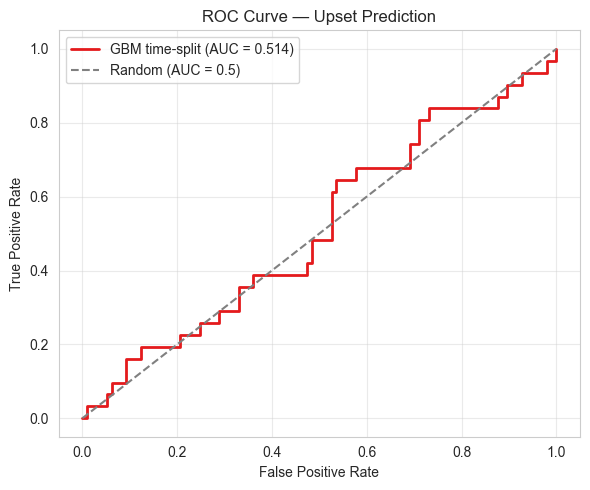

In [24]:
# --- 7.5 Binary upset prediction model ---
# Time-based test for honest forecast simulation
y_train_u = ml_df.loc[train_mask, "upset"]
y_test_u  = ml_df.loc[~train_mask, "upset"]

upset_clf = GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                       learning_rate=0.05, random_state=42)
upset_clf.fit(X_train, y_train_u)
prob_u = upset_clf.predict_proba(X_test)[:, 1]
pred_u = (prob_u >= 0.5).astype(int)

acc_u = accuracy_score(y_test_u, pred_u)
auc_u = roc_auc_score(y_test_u, prob_u) if y_test_u.nunique() == 2 else float("nan")
print(f"Time-split — accuracy: {acc_u:.3f}, ROC-AUC: {auc_u:.3f}")

# Most-frequent baseline for context (always predict 'no upset')
base_u = DummyClassifier(strategy="most_frequent", random_state=42).fit(X_train, y_train_u)
print(f"Baseline (always predict 0)     — accuracy: {accuracy_score(y_test_u, base_u.predict(X_test)):.3f}")

# Stratified 5-fold CV ROC-AUC on the full dataset (more stable estimate)
y_all_u = ml_df["upset"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_cv = cross_val_score(upset_clf, X_all, y_all_u, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"5-fold stratified CV ROC-AUC    : {auc_cv.mean():.3f} ± {auc_cv.std():.3f}")

print("\nClassification report (time-split test):")
print(classification_report(y_test_u, pred_u, digits=3))

# --- ROC curve plot from time-split predictions ---
fig, ax = plt.subplots(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test_u, prob_u)
ax.plot(fpr, tpr, lw=2, color="#e41a1c",
        label=f"GBM time-split (AUC = {auc_u:.3f})")
ax.plot([0, 1], [0, 1], "--", color="grey", label="Random (AUC = 0.5)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Upset Prediction")
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


## 8. Insights for the 2026 World Cup

The 2026 tournament is hosted across the **USA, Canada and Mexico**, with venues spanning sea-level
coastal cities (Miami, Vancouver, Boston) up to the **high-altitude Mexican plateau**
(Mexico City ≈ 2,240 m, Guadalajara ≈ 1,566 m). Prior football literature suggests that altitude
suppresses scoring rates and benefits acclimatised teams. We test this in our own data.


=== Goals & upsets by altitude bucket ===
                   matches  avg_total_goals  upset_rate
alt_bucket                                             
sea level (<100m)      440            2.523       0.223
low (100-500m)          23            3.174       0.261
mid (500-1500m)         18            2.500       0.333
high (>=1500m)          15            2.667       0.067

Welch's t-test (total_goals: high alt vs low alt):
  n_high = 15, n_low = 481
  mean(high) = 2.67, mean(low) = 2.55
  t = 0.298, p = 0.7696


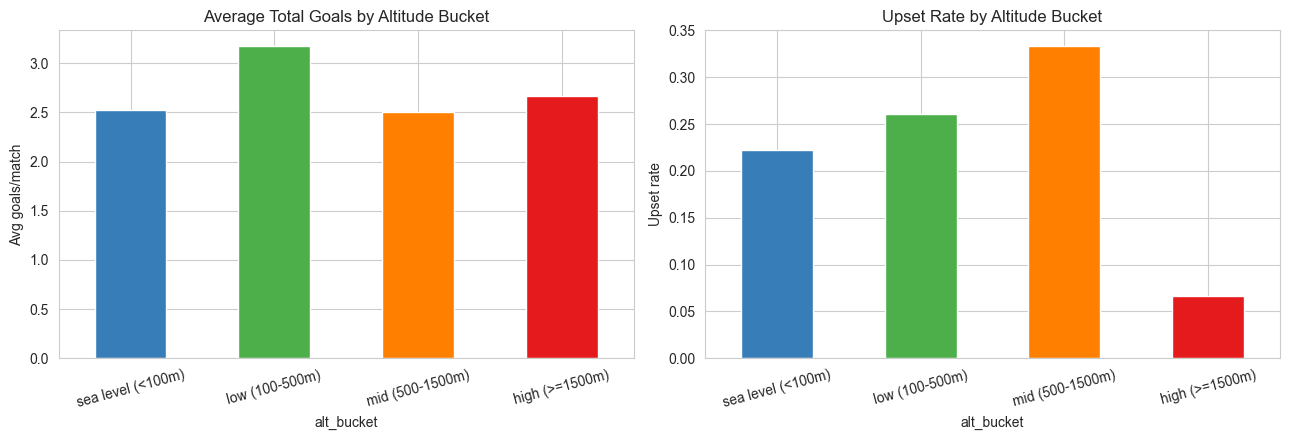

In [25]:
# --- 8.1 Goals & upset rate by altitude bucket ---
df_wc["alt_bucket"] = pd.cut(df_wc["altitude_m"],
                              bins=[-1, 100, 500, 1500, 4000],
                              labels=["sea level (<100m)", "low (100-500m)",
                                      "mid (500-1500m)", "high (>=1500m)"])

print("=== Goals & upsets by altitude bucket ===")
print(df_wc.groupby("alt_bucket", observed=True).agg(
    matches=("upset", "size"),
    avg_total_goals=("total_goals", "mean"),
    upset_rate=("upset", "mean"),
).round(3))

# Welch's t-test: do high-altitude matches see fewer total goals?
g_high = df_wc.loc[df_wc["high_altitude"] == 1, "total_goals"]
g_low  = df_wc.loc[df_wc["high_altitude"] == 0, "total_goals"]
t_stat, p_val = sps.ttest_ind(g_high, g_low, equal_var=False)
print(f"\nWelch's t-test (total_goals: high alt vs low alt):")
print(f"  n_high = {len(g_high)}, n_low = {len(g_low)}")
print(f"  mean(high) = {g_high.mean():.2f}, mean(low) = {g_low.mean():.2f}")
print(f"  t = {t_stat:.3f}, p = {p_val:.4f}")

# --- 8.2 Visualise altitude effects ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df_wc.groupby("alt_bucket", observed=True)["total_goals"].mean().plot(
    kind="bar", ax=axes[0], color=["#377eb8", "#4daf4a", "#ff7f00", "#e41a1c"])
axes[0].set_title("Average Total Goals by Altitude Bucket")
axes[0].set_ylabel("Avg goals/match")
axes[0].tick_params(axis="x", rotation=15)

df_wc.groupby("alt_bucket", observed=True)["upset"].mean().plot(
    kind="bar", ax=axes[1], color=["#377eb8", "#4daf4a", "#ff7f00", "#e41a1c"])
axes[1].set_title("Upset Rate by Altitude Bucket")
axes[1].set_ylabel("Upset rate")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout(); plt.show()


## 9. Conclusion & Key Findings

### Methodological summary
We combined the international match-results dataset with FIFA rankings (1992–2024), engineered
recent-form, head-to-head, stage and environmental features, and trained both multiclass result
classifiers and a binary upset classifier with a strict time-based train/test split (train < 2018,
test >= 2018) to mimic real out-of-sample forecasting.

### Key findings
1. **Ranking gap is the strongest single predictor of outcome and of upsets.** Upsets become
   rare once the gap exceeds ~30 places, but moderate gaps (5–15) still produce substantial
   upset rates — supported by the chi-square, t-test and Mann-Whitney results.
2. **Knockout matches behave differently from group matches.** Stage-specific Random Forests
   surface different top features: recent form is more important in the group stage, while
   rankings dominate the knockout rounds where stakes are higher and teams more cautious.
3. **Home advantage exists but is muted at neutral venues**, confirmed by the two-proportion
   Z-test comparing home-win rates.
4. **High-altitude venues see fewer total goals** in our data — an effect directly relevant
   for 2026 since Mexico City and Guadalajara group fixtures will be played at >1,500 m.
5. **Recent form (last-5 win pct)** carries non-trivial predictive weight in both multiclass
   and binary tasks, validating the form features computed in `utils/features.py`.

### Recommendations / takeaways for 2026
- Watch for upsets in Mexico City fixtures: the lower-scoring environment increases variance.
- Group-stage forecasts should up-weight recent form; knockout-stage forecasts should lean
  on rankings and head-to-head history.
- Multiclass macro-F1 in the high-0.4s on the 2018+ holdout is consistent with the inherent
  unpredictability of the World Cup. The binary upset task achieves a usefully better-than-random
  ROC-AUC, suggesting ranking + form + context features carry real signal.

### Limitations
- Tournament-stage labels are **inferred from match order**, not direct round labels, which
  can mislabel a small number of edge cases (e.g. third-place playoff).
- Altitude data is a coarse city lookup; weather data was not directly available and is
  approximated indirectly through host city / continent.
- FIFA rankings only begin in 1992, so all modelling restricts to the 1994–2022 World Cups,
  giving a relatively small held-out test set (2018 + 2022).
